In this file, I built a tiered model that first predicts three priority levels—low, medium, and high—and then applies a second model to determine whether high-priority tickets are actually critical. I explored this approach due to the unusual AUC/ROC behavior observed when predicting all five classes simultaneously. While the first tier performed well, the second tier still showed an unusually high AUC for critical tickets. This is likely driven by the limited number of critical tickets and the complete absence of English-language critical examples in the dataset.

In [21]:
from datasets import load_dataset
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

######## Run this if you want the untranslated dataset
# df = dataset["train"].to_pandas() 

######## Run this if you want the translated dataset
df = pd.read_csv("df_translated.csv")


# df.head()

# Initial Text Cleaning

In [2]:
import re

def clean_text(text):
    text = text.lower()
    
    # remove common greeting prefixes at start of message
    text = re.sub(r"^(dear\s+)?(customer\s+(support|service)\s*(team)?|support\s*team)[\s,:\-]*", "", text)

    # remove generic greetings, urls, signnatures, and whitespace
    text = re.sub(r"^(hello|hi|greetings)[\s,:\-]*", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"(best regards|kind regards|sincerely).*", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [3]:
# For english, change all df's to english

# Clean Subject and Body
df["body"] = df["body"].astype(str).apply(clean_text)
df["subject"] = df["subject"].astype(str).apply(clean_text)

# Concat subject and body into one "Text"
df["text"] = df["subject"] + " " + df["body"]

# Fill na with unknown
df["version"] = df["version"].fillna("unknown").astype(str)
# I doubt version would be a reasonable predictor but we shall see

# Combine all Tags into one
tag_cols = [f"tag_{i}" for i in range(1,9)]
df["all_tags"] = df[tag_cols].fillna("").agg(" ".join, axis=1)

## Train test split


In [4]:
df_tier1 = df.copy()

# Create a copy for the first tier, where critical ==> high, very_low ==> low
df_tier1["priority_tier1"] = df_tier1["priority"].replace({
    "critical": "high",
    "very_low": "low"
})

In [5]:
from sklearn.model_selection import train_test_split

X_t1 = df_tier1.drop(columns=["priority", "priority_tier1"])
y_t1 = df_tier1["priority_tier1"]

X_t1_train, X_t1_test, y_t1_train, y_t1_test = train_test_split(
    X_t1, y_t1, test_size=0.2, stratify=y_t1, random_state=42
)

# 1st tier

## Preprocessing and Transforming

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

text_col = "text"
cat_cols = ["type", "version", "all_tags"] # , "language"

preprocessor_t1 = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=80000,
            ngram_range=(1, 3),
            stop_words="english",
            sublinear_tf=True,
            max_df=0.85,
            norm=None,
            min_df=5
        ), text_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

## Pipeline and Fit

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_tier1 = Pipeline([
    ("preprocessing", preprocessor_t1),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

pipeline_tier1.fit(X_t1_train, y_t1_train)
print("Tier 1 training complete.")

/Users/kylebeedon/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Tier 1 training complete.


## Tier 1 Evaluation 

In [8]:
from sklearn.metrics import classification_report, roc_auc_score

y_t1_pred = pipeline_tier1.predict(X_t1_test)

print("=== Tier 1 Classification Report ===")
print(classification_report(y_t1_test, y_t1_pred))

auc_t1 = roc_auc_score(
    y_t1_test,
    pipeline_tier1.predict_proba(X_t1_test),
    multi_class="ovr",
    average=None,
    labels=pipeline_tier1.classes_
)

print("Per-class AUC (Tier 1):")
for cls, score in zip(pipeline_tier1.classes_, auc_t1):
    print(f"  {cls:>10}: {score:.3f}")

=== Tier 1 Classification Report ===
              precision    recall  f1-score   support

        high       0.82      0.82      0.82      4768
         low       0.80      0.78      0.79      2910
      medium       0.79      0.79      0.79      4675

    accuracy                           0.80     12353
   macro avg       0.80      0.80      0.80     12353
weighted avg       0.80      0.80      0.80     12353

Per-class AUC (Tier 1):
        high: 0.927
         low: 0.931
      medium: 0.910


# 2nd Tier

## Building Training Data

In [9]:
# Only use tickets that are truly "high" or "critical" in the original labels
# Filter to German only since ALL critical tickets are German —
df_tier2 = df[df["priority"].isin(["high", "critical"]) & (df["language"] == "de")].copy()

# Apply the same text cleaning
df_tier2["body"] = df_tier2["body"].astype(str).apply(clean_text)
df_tier2["subject"] = df_tier2["subject"].astype(str).apply(clean_text)
df_tier2["text"] = df_tier2["subject"] + " " + df_tier2["body"]
df_tier2["version"] = df_tier2["version"].fillna("unknown").astype(str)
df_tier2["all_tags"] = df_tier2[[f"tag_{i}" for i in range(1, 9)]].fillna("").agg(" ".join, axis=1)

print("Tier 2 label distribution (German only):")
print(df_tier2["priority"].value_counts())

Tier 2 label distribution (German only):
priority
high        11008
critical     1914
Name: count, dtype: int64


## Tier 2 train/test split

In [10]:
X_t2 = df_tier2.drop(columns=["priority"])
y_t2 = df_tier2["priority"]

X_t2_train, X_t2_test, y_t2_train, y_t2_test = train_test_split(
    X_t2, y_t2, test_size=0.2, stratify=y_t2, random_state=42
)

print(f"Tier 2 training set: {y_t2_train.value_counts().to_dict()}")
print(f"Tier 2 test set:     {y_t2_test.value_counts().to_dict()}")

Tier 2 training set: {'high': 8806, 'critical': 1531}
Tier 2 test set:     {'high': 2202, 'critical': 383}


## Preprocessing

In [12]:
cat_cols_t2 = ["type", "version", "all_tags"]   # no "language" (it was a leaking feature)

preprocessor_t2 = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=80000,
            ngram_range=(1, 3),
            stop_words="english",       # <-- None instead of "english" (text is German)
            sublinear_tf=True,
            max_df=0.85,
            norm=None,
            min_df=2
        ), text_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_t2)
    ]
)

## Pipeline and fit

In [13]:
pipeline_tier2 = Pipeline([
    ("preprocessing", preprocessor_t2),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced", 
        n_jobs=-1
    ))
])

pipeline_tier2.fit(X_t2_train, y_t2_train)
print("Tier 2 training complete.")

Tier 2 training complete.


/Users/kylebeedon/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## Evaluations

In [15]:
y_t2_pred = pipeline_tier2.predict(X_t2_test)

print("=== Tier 2 Classification Report ===")
print(classification_report(y_t2_test, y_t2_pred))

auc_t2 = roc_auc_score(
    y_t2_test,
    pipeline_tier2.predict_proba(X_t2_test)[:, 1],  # binary, so just positive class
    labels=["critical"]
)
print(f"\nCritical AUC (Tier 2): {auc_t2:.3f}")

=== Tier 2 Classification Report ===
              precision    recall  f1-score   support

    critical       0.93      0.95      0.94       383
        high       0.99      0.99      0.99      2202

    accuracy                           0.98      2585
   macro avg       0.96      0.97      0.96      2585
weighted avg       0.98      0.98      0.98      2585


Critical AUC (Tier 2): 0.997


## Some Sample tickets to test on 

In [16]:
# Utilized Claude to create a sample of seemingly critical ticekets to test on the model
sample_tickets = pd.DataFrame([
    {"subject": "Spam Filtering Severely Impaired by API Outage","body": "we're currently dealing with a critical issue: the spam filtering system has failed due to an api error that occurred after moderation. the stack exchange api v2.3 outage is preventing proper processing of unmoderated spam posts, which is causing approval requests to fail. this needs to be addressed immediately to avoid potential violations of community guidelines and reputational risk. we'd greatly appreciate your prompt assistance and escalation of this issue.","answer": None, "type": None, "queue": None, "language": "en", "version": "unknown", "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None, "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
    {"subject": "Urgent: Fitness Class Scheduling System Down","body": "we're currently experiencing a critical outage in the mindbody system that's impacting both client bookings and payments. given how serious this is, a quick technical resolution is needed to avoid potential member churn. i've already tried restarting the system, but the issue is still ongoing. could you please look into this as soon as possible and advise on a solution?", "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",  "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None, "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
    {"subject": "Complete Database Failure — Immediate Escalation Required","body": "we are facing a complete database failure that has brought all operations to a halt. no transactions are being processed and customer data is inaccessible. our engineering team has been unable to restore connectivity for the past three hours. this is a severity-1 incident and requires immediate escalation. every minute of downtime is resulting in direct financial loss.","answer": None, "type": None, "queue": None, "language": "en", "version": "unknown", "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,"tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
    {"subject": "Critical: Payment Processing System Offline", "body": "our payment gateway has been completely offline for the last two hours, resulting in failed transactions across all customer accounts. we are unable to process any purchases or refunds. this outage is causing significant revenue loss and customer complaints are escalating rapidly. we need an emergency response immediately.", "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown","tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,"tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": "" },
    {"subject": "Security Breach Detected — Unauthorized Access to Customer Data","body": "we have detected unauthorized access to our customer database within the last hour. sensitive personal and financial data may have been compromised. we have taken the affected systems offline but require immediate assistance from your security team to contain the breach and assess the full scope of the incident. this is a critical security emergency.", "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown","tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None, "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
    {"subject": "Total Service Outage Affecting All Users", "body": "our platform has been completely unreachable for all users since approximately 09:00 utc. the error logs indicate a cascading failure originating from the load balancer. all downstream services are affected including authentication, data retrieval, and reporting. we have exhausted all internal recovery options and need urgent support to restore service.","answer": None, "type": None, "queue": None, "language": "en", "version": "unknown","tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,"tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
    {"subject": "Critical Data Loss Following Failed System Migration","body": "following last night's scheduled system migration, we have discovered that a significant portion of customer records has been lost. backups from the past 48 hours appear to be corrupted and unrestorable. this is causing severe operational disruption and potential regulatory violations around data retention. we need an emergency response team assigned immediately.","answer": None, "type": None, "queue": None, "language": "en", "version": "unknown","tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None, "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
    {"subject": "Production Server Crash — All Services Down","body": "our primary production server has crashed and all services are currently unavailable. the crash occurred without warning and our on-call engineer has been unable to bring the system back online. customers are unable to log in, access data, or complete any transactions. we require immediate emergency support to diagnose and resolve this critical outage.","answer": None, "type": None, "queue": None, "language": "en", "version": "unknown", "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None, "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": "" },
    {"subject": "Urgent: API Failure Causing Cascading System Errors","body": "a failure in our core api is triggering cascading errors across multiple dependent services. order processing, inventory management, and customer notifications have all gone down as a result. we are losing approximately $10,000 per hour in failed transactions. our team has been troubleshooting for four hours with no resolution. please escalate this immediately.", "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown","tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,"tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": "" },
    {"subject": "Critical: Cloud Storage Failure — Patient Records Inaccessible","body": "our cloud storage system has failed and all patient records are currently inaccessible. clinical staff are unable to retrieve medical histories, prescriptions, or appointment data, which is directly impacting patient care. this constitutes a critical operational and regulatory emergency. we require immediate escalation and restoration of access as a matter of urgency.","answer": None, "type": None, "queue": None, "language": "en", "version": "unknown","tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,"tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
    {"subject": "DRINGEND: Ausfall des Produktionssystems – Alle Benutzer betroffen", "body":"Unsere Produktionsumgebung ist derzeit ausgefallen, und die Benutzer können nicht auf die Plattform zugreifen. Wir erhalten aus allen Regionen zahlreiche Meldungen über fehlgeschlagene Anmeldeversuche und Timeouts. Erste Untersuchungen deuten auf wiederholte Serverfehler sowie Ausfälle bei der Datenbankverbindung hin.Dieses Problem blockiert sämtliche Geschäftsabläufe – einschließlich der Kundentransaktionen – und führt zu unmittelbaren Umsatzeinbußen. Versuche, das System neu zu starten, haben das Problem bislang nicht behoben; zudem signalisiert das System-Monitoring eine Eskalation der Ausfälle. Dies erfordert umgehende Aufmerksamkeit sowie eine Einstufung als höchste Priorität. Bitte informieren Sie uns über die nächsten Schritte und teilen Sie uns schnellstmöglich eine geschätzte Zeitspanne für die Fehlerbehebung mit.","answer": None, "type":None, "queue": None, "language": "de", "version": "unknown","tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,"tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""},
])

In [23]:
# df.iloc[28595].body
# df[df.priority == "critical"]

# Running both tiers

In [17]:
# Run both tiers end-to-end on new tickets

# Two tiered prediction 
def predict_priority(tickets_df):
    """
    Takes a DataFrame of raw tickets.
    Returns the DataFrame with final priority predictions.
    
    Flow:
      - Tier 1 predicts low / medium / high
      - Tickets predicted as "high" go to Tier 2
      - Tier 2 upgrades some "high" → "critical"
    """
    df_in = tickets_df.copy()

    # Apply text cleaning
    df_in["body"] = df_in["body"].astype(str).apply(clean_text)
    df_in["subject"] = df_in["subject"].astype(str).apply(clean_text)
    df_in["text"] = df_in["subject"] + " " + df_in["body"]
    df_in["version"] = df_in["version"].fillna("unknown").astype(str)
    df_in["all_tags"] = df_in[[f"tag_{i}" for i in range(1, 9)]].fillna("").agg(" ".join, axis=1)

    
    # Tier 1
    tier1_preds = pipeline_tier1.predict(df_in)
    df_in["tier1_pred"] = tier1_preds

    
    # Tier 2
    df_in["final_pred"] = df_in["tier1_pred"]  # default to tier 1 result

    high_mask = df_in["tier1_pred"] == "high"
    if high_mask.sum() > 0:
        tier2_preds = pipeline_tier2.predict(df_in[high_mask])
        df_in.loc[high_mask, "final_pred"] = tier2_preds

    return df_in[["subject", "tier1_pred", "final_pred"]]


# Run on sample tickets
results = predict_priority(sample_tickets)
print(results.to_string(index=False))

                                                           subject tier1_pred final_pred
                    spam filtering severely impaired by api outage       high   critical
                      urgent: fitness class scheduling system down       high   critical
         complete database failure — immediate escalation required       high   critical
                       critical: payment processing system offline       high   critical
   security breach detected — unauthorized access to customer data       high   critical
                          total service outage affecting all users       high       high
              critical data loss following failed system migration       high   critical
                       production server crash — all services down       high       high
               urgent: api failure causing cascading system errors       high       high
    critical: cloud storage failure — patient records inaccessible       high   critical
dringend: ausfall des

# Tier 2 performance

In [18]:
# Check Tier 2 performance on real held-out data
print("=== Tier 2 Classification Report ===")
print(classification_report(y_t2_test, pipeline_tier2.predict(X_t2_test)))

# See what probability threshold Tier 2 is using for "critical"
t2_probs = pipeline_tier2.predict_proba(X_t2_test)
critical_idx = list(pipeline_tier2.classes_).index("critical")

import pandas as pd
prob_df = pd.DataFrame({
    "true_label": y_t2_test.values,
    "critical_prob": t2_probs[:, critical_idx],
    "pred": pipeline_tier2.predict(X_t2_test)
})

print("\nAverage critical probability for truly critical tickets:")
print(prob_df[prob_df["true_label"] == "critical"]["critical_prob"].describe())

print("\nAverage critical probability for truly high tickets:")
print(prob_df[prob_df["true_label"] == "high"]["critical_prob"].describe())

=== Tier 2 Classification Report ===
              precision    recall  f1-score   support

    critical       0.93      0.95      0.94       383
        high       0.99      0.99      0.99      2202

    accuracy                           0.98      2585
   macro avg       0.96      0.97      0.96      2585
weighted avg       0.98      0.98      0.98      2585


Average critical probability for truly critical tickets:
count    383.000000
mean       0.926909
std        0.189898
min        0.002716
25%        0.974207
50%        0.997672
75%        0.999741
max        1.000000
Name: critical_prob, dtype: float64

Average critical probability for truly high tickets:
count    2.202000e+03
mean     1.795092e-02
std      8.995838e-02
min      4.440892e-16
25%      8.247204e-08
50%      1.228182e-05
75%      5.788175e-04
max      9.971072e-01
Name: critical_prob, dtype: float64


## ROC Curve: Tier 1 (multiclass OvR)

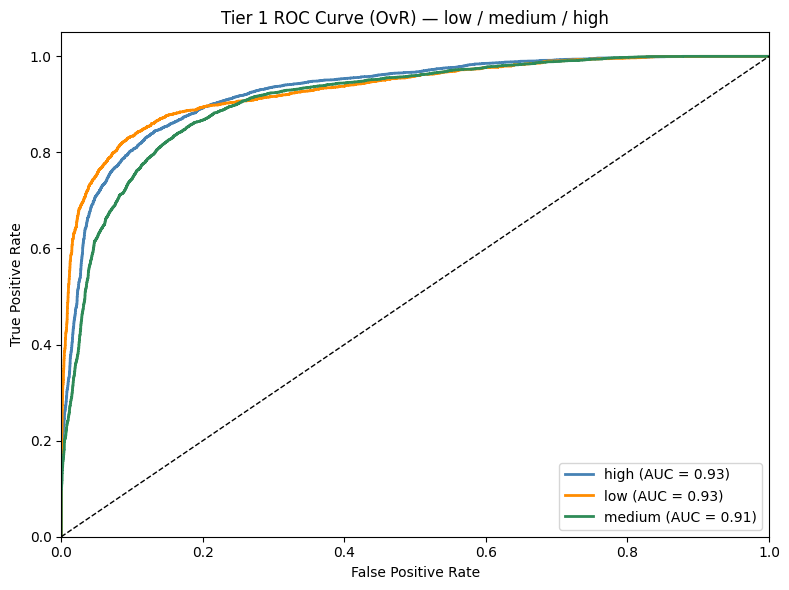

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize Tier 1 test labels
t1_classes = pipeline_tier1.classes_
y_t1_bin = label_binarize(y_t1_test, classes=t1_classes)
y_t1_probs = pipeline_tier1.predict_proba(X_t1_test)

plt.figure(figsize=(8, 6))
colors = ["steelblue", "darkorange", "seagreen"]

for i, (cls, color) in enumerate(zip(t1_classes, colors)):
    fpr, tpr, _ = roc_curve(y_t1_bin[:, i], y_t1_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tier 1 ROC Curve (OvR) — low / medium / high")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## ROC Curve: Tier 2 (binary: high vs critical)

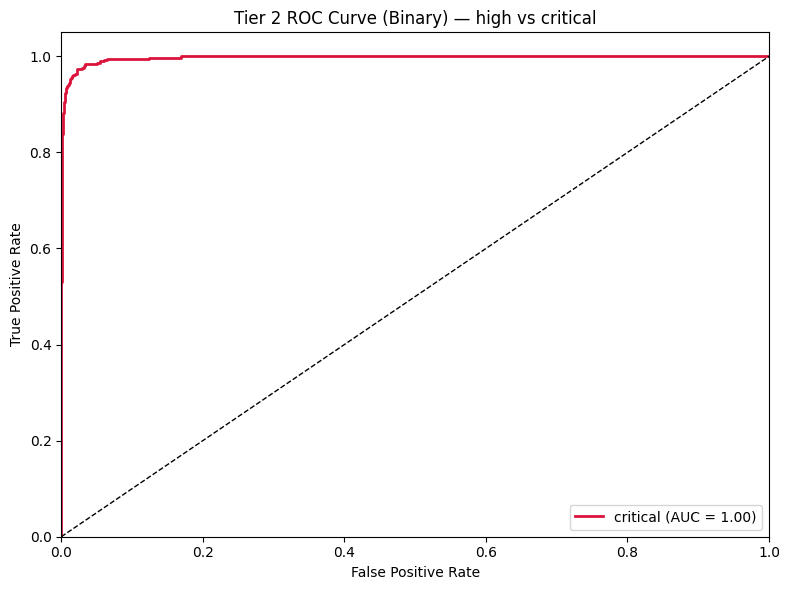

In [20]:
critical_idx = list(pipeline_tier2.classes_).index("critical")
y_t2_probs = pipeline_tier2.predict_proba(X_t2_test)[:, critical_idx]

fpr, tpr, _ = roc_curve(y_t2_test, y_t2_probs, pos_label="critical")
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="crimson", lw=2, label=f"critical (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tier 2 ROC Curve (Binary) — high vs critical")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()